In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns


In [ ]:
df = pd.read_csv('https://github.com/OpenClassrooms-Student-Center/Design-Statistical-Models/raw/refs/heads/master/data/advertising.csv')

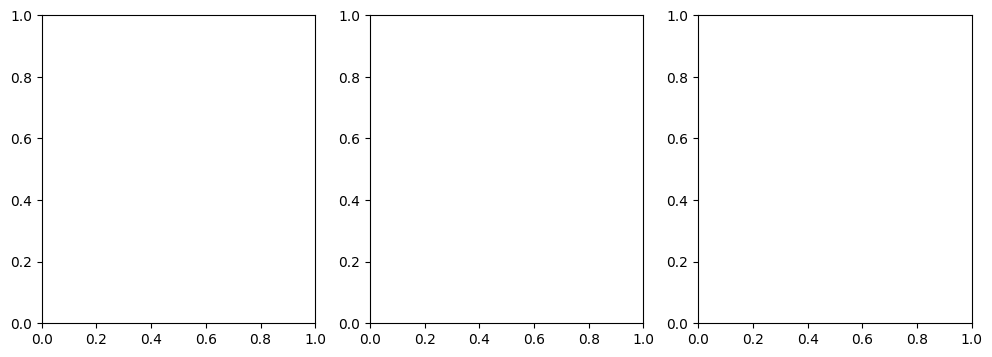

In [ ]:
fig, axs = plt.subplots(1, 3, figsize = (12, 4))

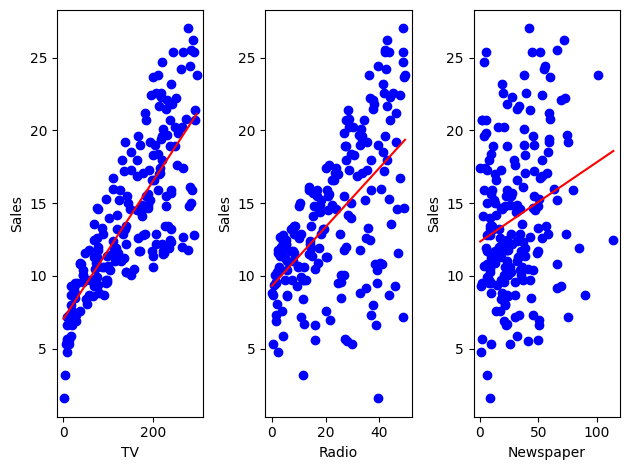

In [ ]:
for k, col in np.ndenumerate(['TV', 'Radio', 'Newspaper']):
  sing = np.polyfit(df[col], df.Sales, 1)
  sing_x = np.linspace(df[col].min(), df[col].max(), 3)
  sing_y = sing[0] * sing_x + sing[1]

  plt.subplot(1,3,k[0]+1)
  plt.scatter(df[col], df.Sales, color = 'blue')
  plt.plot(sing_x, sing_y, color = 'red')
  plt.xlabel(col)
  plt.ylabel('Sales')
plt.tight_layout()

In [ ]:
df.corr()['Sales']

,Sales
TV,0.782224
Radio,0.576223
Newspaper,0.228299
Sales,1.000000


In [ ]:
X = df['TV']
X = sm.add_constant(X)
y = df['Sales']
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.47e-42
Time:                        12:19:02   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

In [ ]:
results.fittedvalues = results.params['TV'] * df.TV + results.params['const']

In [ ]:
df['fitted'] = results.fittedvalues

In [ ]:
df.sort_values(by = 'TV', ascending=True, inplace=True)

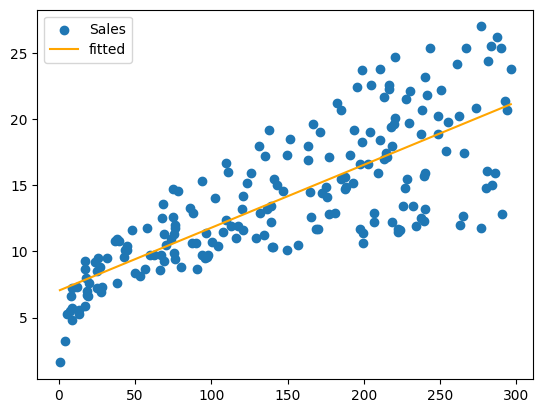

In [ ]:
plt.scatter(df.TV, df.Sales, label = 'Sales')
plt.plot(df.TV, df.fitted, label ='fitted', color='orange')
plt.legend()


<Axes: xlabel='TV', ylabel='Sales'>

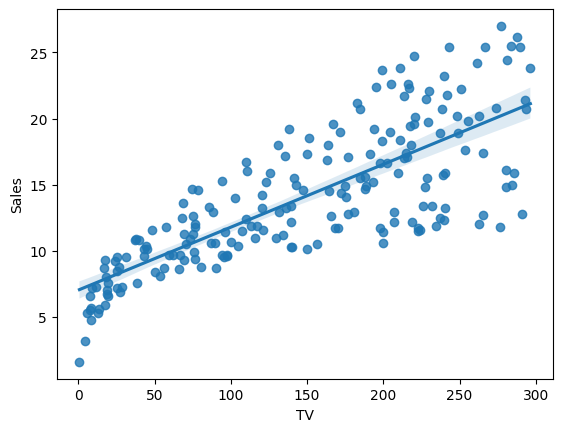

In [ ]:
sns.regplot(x=df['TV'], y=df.Sales)